# Пример чтения файлов формата `.bag`
В данном блокноте приведен пример чтения технических данных из Робота Unitree A1 ИТ-Центра МАИ по имени Дора.
Данный формат широко распространен для записи технических параметров в системах ROS

Установка необходимых пакетов (могут быть проблемы при установке)

In [1]:
%pip install bagpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.4/100.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.5/423.5 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.2 MB/s eta 0:00:00
  Created wheel for gnupg: filename=gnupg-2.3.1-py3-none-any.whl size=94614 sha256=ef531340524146c1dd4b7bb96625cbc691c1c80de9a5c7c42ae45ecf9ec9edb4
  Stored in directory

Подключаем необходимые библиотеки:

In [2]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
b = bagreader("./20230117_183740.bag")

[INFO]  Successfully created the data folder ./20230117_183740.


Посмотрим какие данные сохранены в файле

In [8]:
#Если хотим посмотреть все топики в файле
#pd.set_option('display.max_rows', None)
b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
...,...,...,...,...
102,/device_0/sensor_2/option/Frames_Queue_Size/de...,std_msgs/String,1,NaN
103,/device_0/sensor_2/option/Frames_Queue_Size/value,std_msgs/Float32,1,NaN
104,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/String,1,NaN
105,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/Float32,1,NaN


## Декодирование сообщений из топика

In [9]:
msgsImu_MSG = b.message_by_topic('/device_0/sensor_2/Gyro_0/imu/data')
msgsImu_MSG

'./20230117_183740/device_0-sensor_2-Gyro_0-imu-data.csv'

In [10]:
df_msgsImu = pd.read_csv(msgsImu_MSG)
df_msgsImu

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000015,92990,1673969860,237489462,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.005167,92991,1673969860,242477894,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.009925,92992,1673969860,247466326,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.014939,92993,1673969860,252454519,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.020369,92994,1673969860,257442951,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5026,26.270654,98250,1673969886,500195026,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5027,26.275579,98251,1673969886,505174637,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5028,26.280564,98252,1673969886,510154009,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5029,26.285781,98253,1673969886,515133381,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df_msgsImu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5031 entries, 0 to 5030
Data columns (total 42 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Time                              5031 non-null   float64
 1   header.seq                        5031 non-null   int64  
 2   header.stamp.secs                 5031 non-null   int64  
 3   header.stamp.nsecs                5031 non-null   int64  
 4   header.frame_id                   5031 non-null   int64  
 5   orientation.x                     5031 non-null   float64
 6   orientation.y                     5031 non-null   float64
 7   orientation.z                     5031 non-null   float64
 8   orientation.w                     5031 non-null   float64
 9   orientation_covariance_0          5031 non-null   float64
 10  orientation_covariance_1          5031 non-null   float64
 11  orientation_covariance_2          5031 non-null   float64
 12  orient

Построим график для линейного ускорения датчика по оси Y.
Обратите внимание, что датчик в процессе эксперимента не перемещался, на него воздействовали лишь вибрации от вентилляторов, расположенных в корпусе робота.

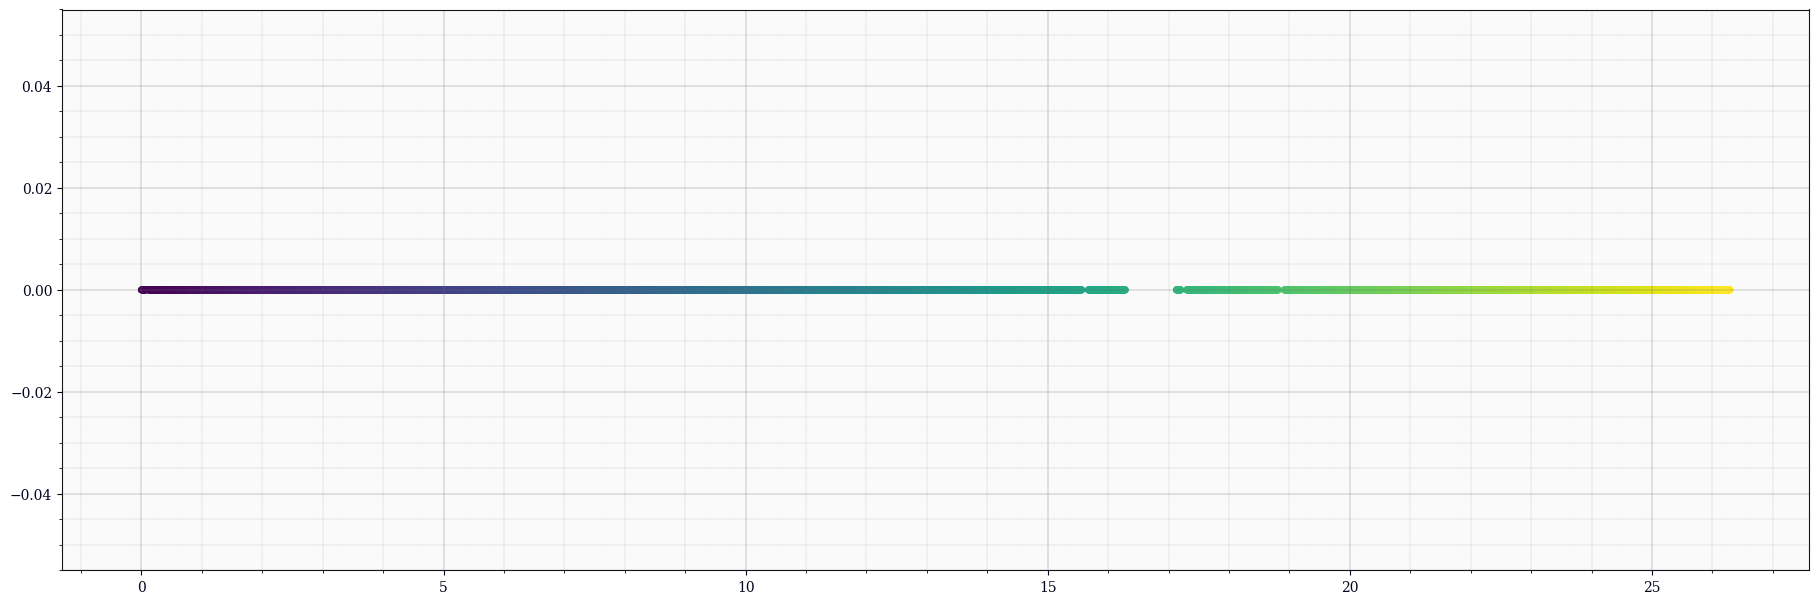

In [12]:
fig, ax = bagpy.create_fig(1)
ax[0].scatter(x='Time', y='linear_acceleration.y', data=df_msgsImu, s= 17, c = 'Time')
plt.show()

## Заглянем в цветную камеру и камеру глубины
На борту робота установлена цветная камера и камера глубины, которые осуществляли съемку в процессе записи bag файла. Доступ к данным можно получить аналогичным способом

In [13]:
sensor_msgsImage_MSG_depth = b.message_by_topic('/device_0/sensor_0/Depth_0/image/data')
sensor_msgsImage_MSG_rgb = b.message_by_topic('/device_0/sensor_1/Color_0/image/data')
sensor_msgsImage_MSG_rgb

'./20230117_183740/device_0-sensor_1-Color_0-image-data.csv'

In [14]:
df_sensor_msgsImage = pd.read_csv(sensor_msgsImage_MSG_rgb)
df_sensor_msgsImage

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.039579,6994,1673969860,210257769,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8d\x94\x8d\x8c...
1,0.106640,6995,1673969860,276888609,1,480,640,rgb8,0,1920,b'\x8c\x8b\x90\x8c\x8b\x90\x8d\x8b\x95\x8c\x8a...
2,0.174092,6996,1673969860,343518496,1,480,640,rgb8,0,1920,b'\x8c\x8e\x96\x8c\x8e\x96\x8a\x8e\x95\x8a\x8e...
3,0.239945,6997,1673969860,410146952,1,480,640,rgb8,0,1920,b'\x8e\x8c\x96\x8d\x8b\x95\x8d\x8b\x95\x8c\x8a...
4,0.307951,6998,1673969860,476774216,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8a\x93\x90\x8b...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.994066,7383,1673969886,155333042,1,480,640,rgb8,0,1920,b'\x88\x89\x91\x87\x88\x90\x87\x85\x8f\x88\x87...
390,26.058981,7384,1673969886,221859217,1,480,640,rgb8,0,1920,b'\x86\x8b\x8f\x85\x8a\x8e\x89\x88\x8f\x89\x88...
391,26.128662,7385,1673969886,288382292,1,480,640,rgb8,0,1920,b'\x86\x8c\x8d\x86\x8c\x8d\x84\x89\x8b\x86\x8c...
392,26.192559,7386,1673969886,354902267,1,480,640,rgb8,0,1920,b'\x87\x86\x8d\x87\x86\x8d\x88\x87\x8e\x88\x87...


In [15]:
df_sensor_msgsImage_depth = pd.read_csv(sensor_msgsImage_MSG_depth)
df_sensor_msgsImage_depth

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.033964,6991,1673969860,210136890,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
1,0.101118,6992,1673969860,276767731,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
2,0.167259,6993,1673969860,343397617,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
3,0.234002,6994,1673969860,410026073,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
4,0.300807,6995,1673969860,476653337,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.986207,7380,1673969886,155212402,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
390,26.053176,7381,1673969886,221738577,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
391,26.119521,7382,1673969886,288261414,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
392,26.186304,7383,1673969886,354781628,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


Далее можно считать изображение из Pandas DataFrame, однако в таком формате его использовать неудобно, поэтому добавим немного магии для преобразования в удобный вид цветного изображения

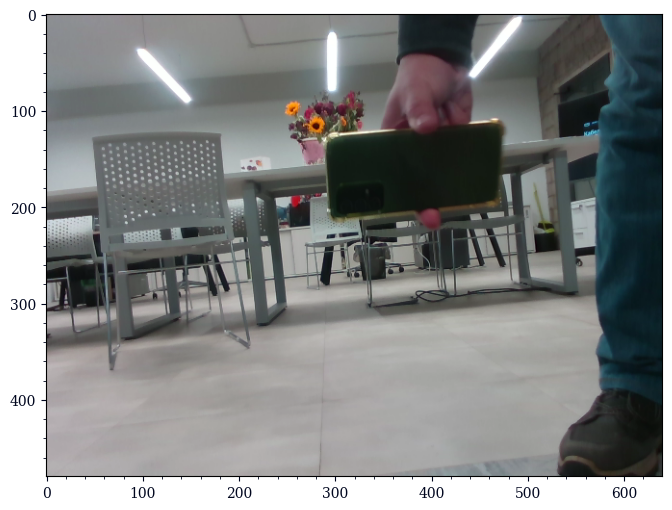

In [16]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage['data'][190]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

Ещё больше магии применим для преобразования изображения с карты глубины встроенной камеры Intel Realsence

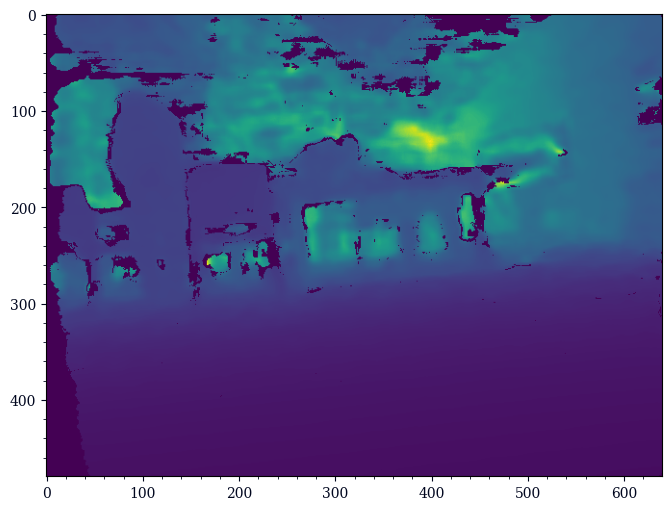

In [17]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage_depth['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.view(np.uint16).reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

## Практическое задание
* Попробуйте считать какие-либо параметры датчиков из данного файла, например, акселерометра
* Постройте параметры в виде графиков в matplotlib

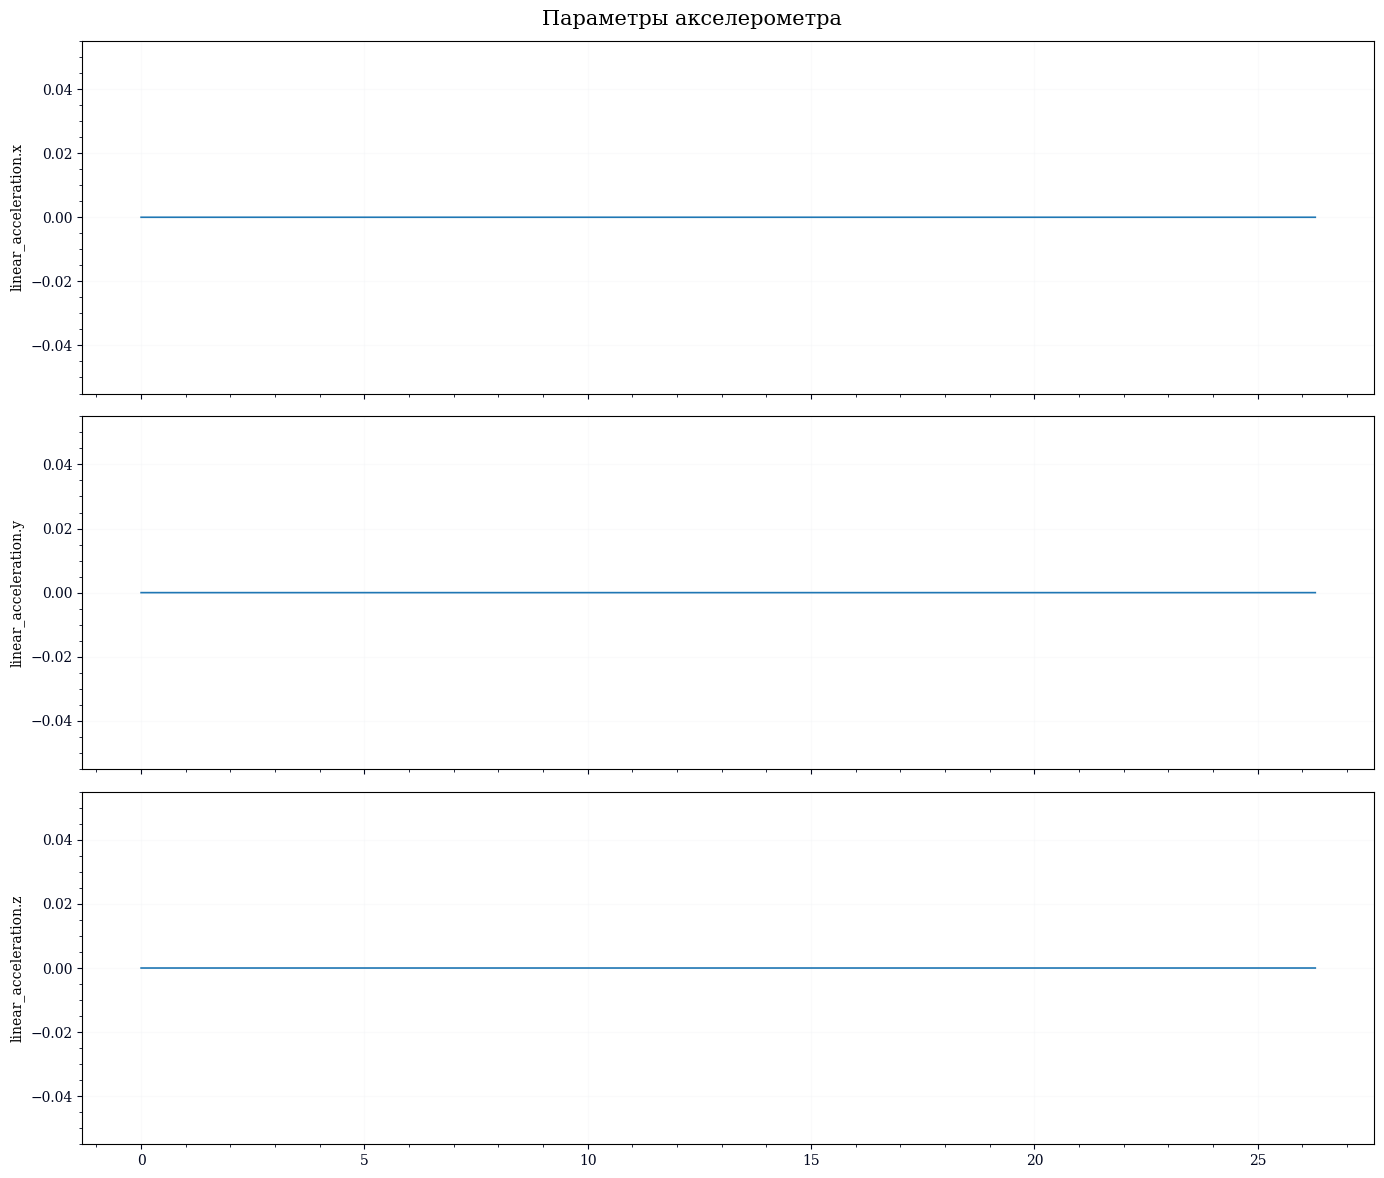

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

acceleration_columns = [
    'linear_acceleration.x',
    'linear_acceleration.y',
    'linear_acceleration.z'
]

for ax, column in zip(axes[:3], acceleration_columns):
    ax.plot(df_msgsImu['Time'], df_msgsImu[column], linewidth=1.2)
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.3)


fig.suptitle('Параметры акселерометра', fontsize=15)
plt.tight_layout()
plt.show()

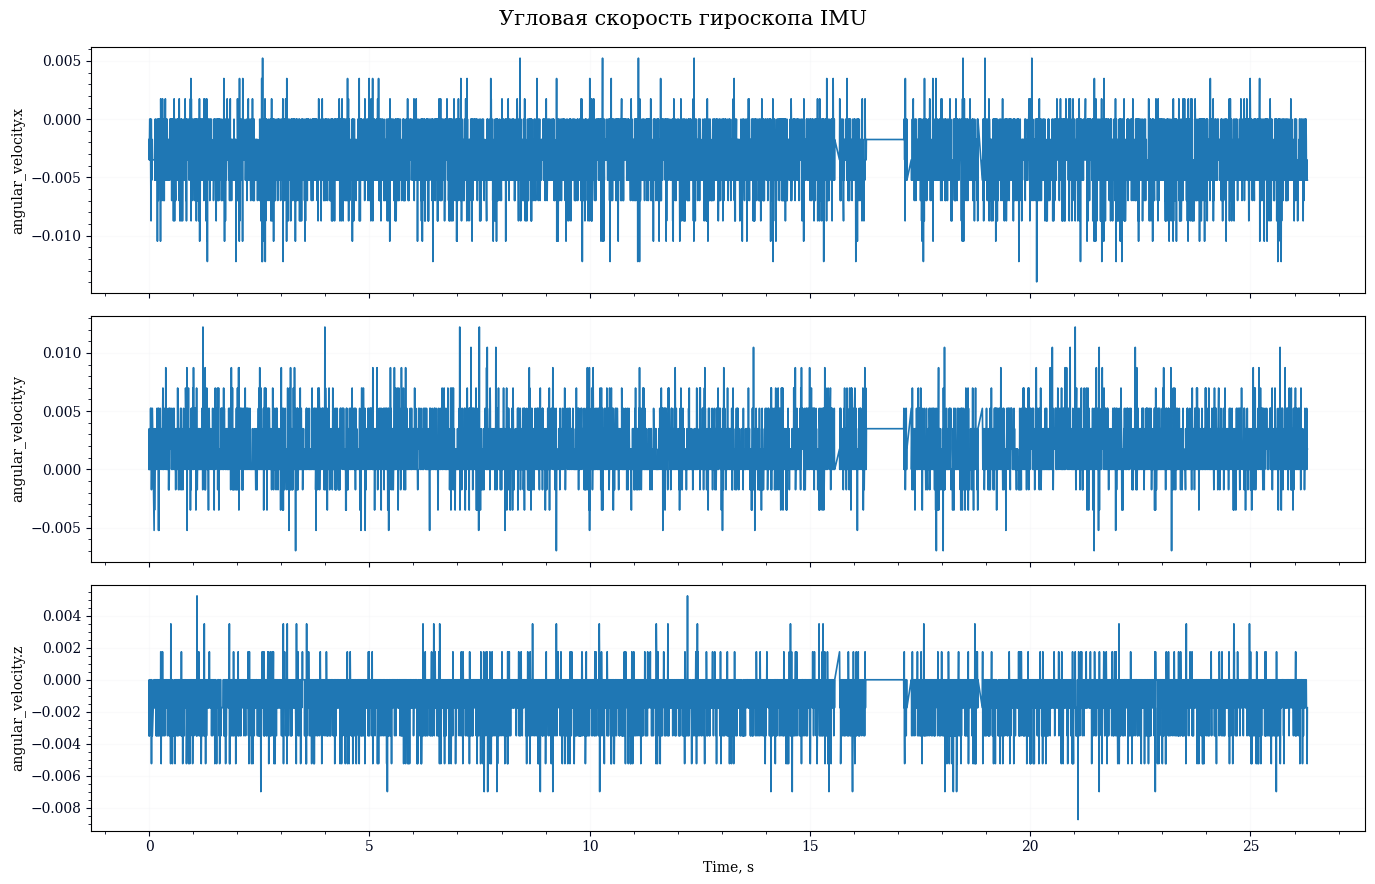

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

gyro_columns = [
    'angular_velocity.x',
    'angular_velocity.y',
    'angular_velocity.z'
]

for ax, column in zip(axes, gyro_columns):
    ax.plot(df_msgsImu['Time'], df_msgsImu[column], linewidth=1.2)
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time, s')
fig.suptitle('Угловая скорость гироскопа IMU', fontsize=15)
plt.tight_layout()
plt.show()



In [28]:
print(    b.topic_table[b.topic_table['Topics'].str.contains(
    'imu|gyro|accel|depth|color|metadata|option',
    case=False,
    na=False
)])


                                                Topics  \
1                /device_0/sensor_0/Depth_0/image/data   
2            /device_0/sensor_0/Depth_0/image/metadata   
3                      /device_0/sensor_0/Depth_0/info   
4          /device_0/sensor_0/Depth_0/info/camera_info   
5                      /device_0/sensor_0/Depth_0/tf/0   
..                                                 ...   
101  /device_0/sensor_2/option/Enable_Motion_Correc...   
102  /device_0/sensor_2/option/Frames_Queue_Size/de...   
103  /device_0/sensor_2/option/Frames_Queue_Size/value   
104  /device_0/sensor_2/option/Global_Time_Enabled/...   
105  /device_0/sensor_2/option/Global_Time_Enabled/...   

                         Types  Message Count  Frequency  
1            sensor_msgs/Image            394  14.988542  
2     diagnostic_msgs/KeyValue           9456        NaN  
3    realsense_msgs/StreamInfo              1        NaN  
4       sensor_msgs/CameraInfo              1        NaN  
5      g

In [32]:
H = 480
W = 640

raw_string = df_sensor_msgsImage_depth['data'][0]
byte_string = raw_string[2:-1].encode('latin1')
escaped_string = byte_string.decode('unicode_escape')
byte_string = escaped_string.encode('latin1')

depth = np.frombuffer(byte_string, np.uint8).view(np.uint16).reshape((H, W))

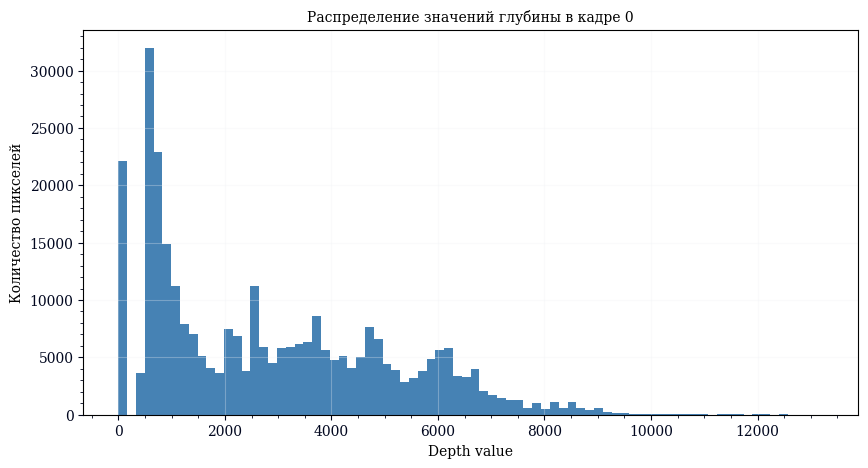

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(depth.flatten(), bins=80, color='steelblue')
plt.title('Распределение значений глубины в кадре 0')
plt.xlabel('Depth value')
plt.ylabel('Количество пикселей')
plt.grid(True, alpha=0.3)
plt.show()


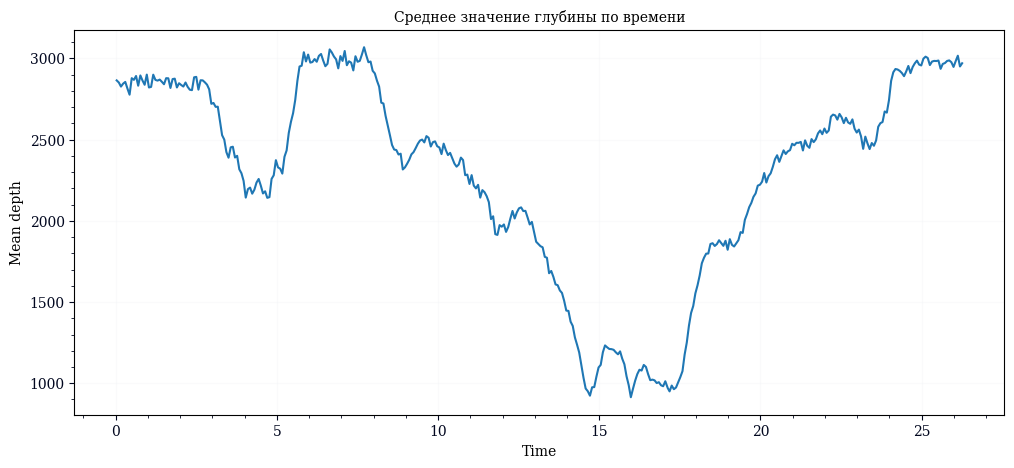

In [34]:
mean_depth = []

for i in range(len(df_sensor_msgsImage_depth)):
    raw_string = df_sensor_msgsImage_depth['data'][i]
    byte_string = raw_string[2:-1].encode('latin1')
    escaped_string = byte_string.decode('unicode_escape')
    byte_string = escaped_string.encode('latin1')
    depth = np.frombuffer(byte_string, np.uint8).view(np.uint16).reshape((H, W))
    mean_depth.append(depth.mean())

plt.figure(figsize=(12, 5))
plt.plot(df_sensor_msgsImage_depth['Time'], mean_depth)
plt.title('Среднее значение глубины по времени')
plt.xlabel('Time')
plt.ylabel('Mean depth')
plt.grid(True, alpha=0.3)
plt.show()


## Дополнительная информация
Дополнительная информация по данному пакету доступна по [ссылке](https://pypi.org/project/bagpy/)